# Task 5: Auto-Tagging Support Tickets Using LLM

**DevelopersHub Corporation — AI/ML Engineering Advanced Internship**

## 1. Problem Statement & Objective

Support teams receive a large volume of free-text tickets every day. Manually tagging
each ticket into the right category (Billing, Technical, Account, Feature Request, etc.)
is slow and inconsistent.

**Objective:** Automatically tag support tickets into categories using a Large Language
Model (LLM), by:

1. Using **prompt engineering** (zero-shot and few-shot) with an LLM to tag tickets
   without any labeled training data.
2. Comparing that **zero-shot** performance against a **fine-tuned** traditional
   supervised classifier trained on labeled tickets.
3. Applying **few-shot learning** (a handful of labeled examples inside the prompt) to
   see how much it improves over pure zero-shot.
4. Outputting the **top-3 most probable tags** for every ticket, not just a single label.

## 2. Approach / Methodology

| Step | Technique | Purpose |
|---|---|---|
| Zero-shot tagging | `facebook/bart-large-mnli` zero-shot-classification pipeline (NLI-based prompt engineering) | Tag tickets with **no training data at all** |
| Few-shot tagging | Instruction-tuned LLM (`google/flan-t5-base`) prompted with a few labeled examples | See if adding examples in the prompt improves accuracy |
| Fine-tuned baseline | TF-IDF + Logistic Regression trained on labeled tickets | A traditional "fine-tuned" model to compare against the prompt-engineered LLM |
| Evaluation | Accuracy, Macro F1, confusion matrix, top-3 accuracy | Quantify which approach works best |

> Note: This notebook is designed to run end-to-end on CPU with small open models so it
> works without any paid API key. If you have access to an LLM API (OpenAI, Anthropic,
> etc.) you can swap the `zero_shot_llm_tag()` / `few_shot_llm_tag()` functions to call
> that API instead — the rest of the notebook (evaluation, comparison, top-3 tags) stays
> the same.


In [1]:
# 1. Install dependencies (uncomment if running for the first time)
# !pip install transformers datasets scikit-learn pandas matplotlib seaborn torch --quiet


In [2]:
import warnings
warnings.filterwarnings("ignore")

import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

pd.set_option("display.max_colwidth", 120)


## 3. Dataset Loading & Preprocessing

We use a free-text support ticket dataset. Two options are supported:

* **Option A (default):** A small, representative synthetic ticket dataset bundled in
  this notebook, so the notebook runs anywhere with zero setup.
* **Option B:** Swap in a real dataset such as the *"Customer Support Ticket"* dataset
  from Kaggle / Hugging Face Hub by loading a CSV with `text` and `label` columns and
  assigning it to `df` below.

The categories used are: `Billing`, `Technical Issue`, `Account`, `Feature Request`,
`General Inquiry`.


In [3]:
CATEGORIES = ["Billing", "Technical Issue", "Account", "Feature Request", "General Inquiry"]

# --- Option A: synthetic but realistic support-ticket dataset -----------------
tickets = [
    ("I was charged twice for my subscription this month, please refund the extra amount.", "Billing"),
    ("My invoice shows an incorrect amount, can you check my last payment?", "Billing"),
    ("Why is my credit card being billed even though I cancelled my plan?", "Billing"),
    ("I need a copy of my last 3 invoices for accounting purposes.", "Billing"),
    ("The payment failed but the amount was still deducted from my bank account.", "Billing"),
    ("The app crashes every time I try to upload a file larger than 10MB.", "Technical Issue"),
    ("I'm getting a 500 error whenever I try to log in from the mobile app.", "Technical Issue"),
    ("The dashboard is not loading, it just shows a blank white screen.", "Technical Issue"),
    ("Export to CSV button does nothing when I click it.", "Technical Issue"),
    ("Video calls keep freezing after a few minutes on the desktop client.", "Technical Issue"),
    ("I can't reset my password, the reset link says it has expired immediately.", "Account"),
    ("Please merge my two accounts into one, I accidentally signed up twice.", "Account"),
    ("How do I change the email address linked to my account?", "Account"),
    ("My account got locked after too many login attempts, please unlock it.", "Account"),
    ("I want to delete my account and all associated data permanently.", "Account"),
    ("It would be great if you could add dark mode to the mobile app.", "Feature Request"),
    ("Can you add support for exporting reports directly to Google Sheets?", "Feature Request"),
    ("Please consider adding two-factor authentication via authenticator apps.", "Feature Request"),
    ("It would help a lot if we could schedule recurring reports automatically.", "Feature Request"),
    ("Any plans to support bulk editing of tickets in the admin panel?", "Feature Request"),
    ("What are your customer support working hours on weekends?", "General Inquiry"),
    ("Do you offer discounts for non-profit organizations?", "General Inquiry"),
    ("Is there a mobile app available for iOS as well as Android?", "General Inquiry"),
    ("Can you tell me more about your data retention policy?", "General Inquiry"),
    ("Where can I find the API documentation for your product?", "General Inquiry"),
]

# Duplicate with slight variations to get a slightly larger, more robust dataset
extra = [
    ("Refund my payment please, I was double charged for the annual plan.", "Billing"),
    ("The billing page shows a wrong currency for my region.", "Billing"),
    ("App keeps freezing on startup after the latest update.", "Technical Issue"),
    ("Getting a sync error between desktop and mobile versions.", "Technical Issue"),
    ("I forgot my password and the recovery email never arrives.", "Account"),
    ("How can I transfer ownership of my account to a colleague?", "Account"),
    ("Please add a calendar integration with Outlook.", "Feature Request"),
    ("Would love a dark theme option for the web dashboard.", "Feature Request"),
    ("What time zone do your support agents operate in?", "General Inquiry"),
    ("Do you have a public status page for uptime?", "General Inquiry"),
]

tickets = tickets + extra
df = pd.DataFrame(tickets, columns=["text", "label"])
df = df.sample(frac=1, random_state=RANDOM_SEED).reset_index(drop=True)

print(f"Total tickets: {len(df)}")
df["label"].value_counts()


Total tickets: 35


label
Billing            7
Account            7
General Inquiry    7
Feature Request    7
Technical Issue    7
Name: count, dtype: int64

In [4]:
# Basic cleaning
def clean_text(t):
    t = t.strip()
    t = " ".join(t.split())
    return t

df["text"] = df["text"].apply(clean_text)
df.head()


,text,label
0,The billing page shows a wrong currency for my region.,Billing
1,"My account got locked after too many login attempts, please unlock it.",Account
2,Where can I find the API documentation for your product?,General Inquiry
3,Do you offer discounts for non-profit organizations?,General Inquiry
4,It would be great if you could add dark mode to the mobile app.,Feature Request


In [5]:
# Train / test split (stratified so every category is represented in both sets)
train_df, test_df = train_test_split(
    df, test_size=0.3, random_state=RANDOM_SEED, stratify=df["label"]
)
print(f"Train size: {len(train_df)}  |  Test size: {len(test_df)}")
test_df.reset_index(drop=True, inplace=True)
train_df.reset_index(drop=True, inplace=True)


Train size: 24  |  Test size: 11


## 4. Model Development

### 4.1 Fine-tuned baseline (TF-IDF + Logistic Regression)

This acts as our "fine-tuned model" reference point — trained specifically on labeled
tickets, the way a traditional supervised classifier (or a fine-tuned BERT) would be.


In [6]:
tfidf = TfidfVectorizer(max_features=3000, ngram_range=(1, 2), stop_words="english")
X_train = tfidf.fit_transform(train_df["text"])
X_test = tfidf.transform(test_df["text"])

clf = LogisticRegression(max_iter=1000, random_state=RANDOM_SEED)
clf.fit(X_train, train_df["label"])

baseline_preds = clf.predict(X_test)
baseline_proba = clf.predict_proba(X_test)

baseline_acc = accuracy_score(test_df["label"], baseline_preds)
baseline_f1 = f1_score(test_df["label"], baseline_preds, average="macro")

print(f"Fine-tuned baseline  ->  Accuracy: {baseline_acc:.3f} | Macro F1: {baseline_f1:.3f}")
print(classification_report(test_df["label"], baseline_preds))


Fine-tuned baseline  ->  Accuracy: 0.545 | Macro F1: 0.527
                 precision    recall  f1-score   support

        Account       0.67      1.00      0.80         2
        Billing       1.00      0.50      0.67         2
Feature Request       0.50      0.50      0.50         2
General Inquiry       0.00      0.00      0.00         3
Technical Issue       0.50      1.00      0.67         2

       accuracy                           0.55        11
      macro avg       0.53      0.60      0.53        11
   weighted avg       0.48      0.55      0.48        11



### 4.2 Zero-shot tagging with an LLM (prompt engineering, no training data)

We use Hugging Face's `zero-shot-classification` pipeline built on
`facebook/bart-large-mnli`. Internally this reframes classification as a natural
language inference prompt: *"This ticket's category is {label}."* — a classic prompt
engineering trick that needs **zero labeled examples**.


In [7]:
from transformers import pipeline

zero_shot_classifier = pipeline(
    "zero-shot-classification",
    model="facebook/bart-large-mnli",
)

def zero_shot_llm_tag(text, labels=CATEGORIES, top_k=3):
    """Return the top_k most probable tags for a ticket using zero-shot prompting."""
    result = zero_shot_classifier(text, candidate_labels=labels, multi_label=True)
    ranked = sorted(zip(result["labels"], result["scores"]), key=lambda x: x[1], reverse=True)
    return ranked[:top_k]

# Quick sanity check
sample_ticket = test_df.iloc[0]["text"]
print("Ticket:", sample_ticket)
print("Top-3 zero-shot tags:", zero_shot_llm_tag(sample_ticket))


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Device set to use cpu


Ticket: Can you tell me more about your data retention policy?
Top-3 zero-shot tags: [('General Inquiry', 0.8459287881851196), ('Account', 0.7331458926200867), ('Feature Request', 0.7164704203605652)]


In [8]:
# Run zero-shot tagging over the whole test set
zero_shot_top1, zero_shot_top3 = [], []

for text in test_df["text"]:
    ranked = zero_shot_llm_tag(text, top_k=3)
    zero_shot_top1.append(ranked[0][0])
    zero_shot_top3.append([label for label, score in ranked])

test_df["zero_shot_top1"] = zero_shot_top1
test_df["zero_shot_top3"] = zero_shot_top3

zero_shot_acc = accuracy_score(test_df["label"], test_df["zero_shot_top1"])
zero_shot_f1 = f1_score(test_df["label"], test_df["zero_shot_top1"], average="macro")

print(f"Zero-shot LLM  ->  Top-1 Accuracy: {zero_shot_acc:.3f} | Macro F1: {zero_shot_f1:.3f}")


Zero-shot LLM  ->  Top-1 Accuracy: 0.727 | Macro F1: 0.727


### 4.3 Few-shot prompting

Now we give the LLM a handful of **labeled examples inside the prompt** (few-shot
learning) and ask an instruction-tuned generative model (`google/flan-t5-base`) to pick
the best category. This tests whether adding examples improves on pure zero-shot.


In [9]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
import torch

flan_tokenizer = AutoTokenizer.from_pretrained("google/flan-t5-base")
flan_model = AutoModelForSeq2SeqLM.from_pretrained("google/flan-t5-base")

# A handful of hand-picked few-shot examples (kept separate from the test set)
FEW_SHOT_EXAMPLES = [
    ("I was charged twice for my subscription this month.", "Billing"),
    ("The app crashes every time I open the settings page.", "Technical Issue"),
    ("I can't log in, it says my password is wrong even after resetting it.", "Account"),
    ("Could you add a dark mode option to the app?", "Feature Request"),
    ("What are your support hours on weekends?", "General Inquiry"),
]

def build_few_shot_prompt(ticket_text, labels=CATEGORIES, examples=FEW_SHOT_EXAMPLES):
    lines = [
        "Classify each support ticket into exactly one of these categories: "
        + ", ".join(labels) + ".",
        "",
    ]
    for ex_text, ex_label in examples:
        lines.append(f"Ticket: {ex_text}\nCategory: {ex_label}")
    lines.append(f"Ticket: {ticket_text}\nCategory:")
    return "\n".join(lines)

def few_shot_llm_tag(text, labels=CATEGORIES, top_k=3):
    """
    Ask flan-t5 to name the best category (few-shot), then fall back to the
    zero-shot classifier's ranking for the top_k list, using the few-shot
    answer as the #1 tag whenever it matches a valid label.
    """
    prompt = build_few_shot_prompt(text, labels)
    inputs = flan_tokenizer(prompt, return_tensors="pt", truncation=True, max_length=512)
    with torch.no_grad():
        output_ids = flan_model.generate(**inputs, max_new_tokens=10)
    prediction = flan_tokenizer.decode(output_ids[0], skip_special_tokens=True).strip()

    # Normalize against known labels
    predicted_label = next((l for l in labels if l.lower() in prediction.lower()), None)

    # Build a top-3 ranking: predicted label first, then fill with zero-shot ranking
    zero_shot_ranked = [label for label, score in zero_shot_llm_tag(text, labels, top_k=len(labels))]
    ranking = []
    if predicted_label:
        ranking.append(predicted_label)
    for label in zero_shot_ranked:
        if label not in ranking:
            ranking.append(label)
    return ranking[:top_k], predicted_label


tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/990M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

In [10]:
# Run few-shot tagging over the test set
few_shot_top1, few_shot_top3 = [], []

for text in test_df["text"]:
    ranking, predicted_label = few_shot_llm_tag(text, top_k=3)
    few_shot_top1.append(ranking[0])
    few_shot_top3.append(ranking)

test_df["few_shot_top1"] = few_shot_top1
test_df["few_shot_top3"] = few_shot_top3

few_shot_acc = accuracy_score(test_df["label"], test_df["few_shot_top1"])
few_shot_f1 = f1_score(test_df["label"], test_df["few_shot_top1"], average="macro")

print(f"Few-shot LLM  ->  Top-1 Accuracy: {few_shot_acc:.3f} | Macro F1: {few_shot_f1:.3f}")


Few-shot LLM  ->  Top-1 Accuracy: 0.364 | Macro F1: 0.313


## 5. Evaluation

We compare all three approaches:

1. **Fine-tuned baseline** (TF-IDF + Logistic Regression) — trained on labeled data.
2. **Zero-shot LLM** — no labeled data at all.
3. **Few-shot LLM** — a handful of labeled examples inside the prompt.

We also report **top-3 accuracy** (is the correct label anywhere in the top 3
suggested tags?), since the task asks for the top-3 most probable tags per ticket.


In [11]:
def top_k_accuracy(true_labels, top_k_preds):
    hits = [true in preds for true, preds in zip(true_labels, top_k_preds)]
    return np.mean(hits)

zero_shot_top3_acc = top_k_accuracy(test_df["label"], test_df["zero_shot_top3"])
few_shot_top3_acc = top_k_accuracy(test_df["label"], test_df["few_shot_top3"])

results = pd.DataFrame({
    "Approach": ["Fine-tuned (TF-IDF + LogReg)", "Zero-shot LLM", "Few-shot LLM"],
    "Top-1 Accuracy": [baseline_acc, zero_shot_acc, few_shot_acc],
    "Macro F1": [baseline_f1, zero_shot_f1, few_shot_f1],
    "Top-3 Accuracy": [np.nan, zero_shot_top3_acc, few_shot_top3_acc],
})
results


,Approach,Top-1 Accuracy,Macro F1,Top-3 Accuracy
0,Fine-tuned (TF-IDF + LogReg),0.545455,0.526667,NaN
1,Zero-shot LLM,0.727273,0.726667,1.0
2,Few-shot LLM,0.363636,0.313333,1.0


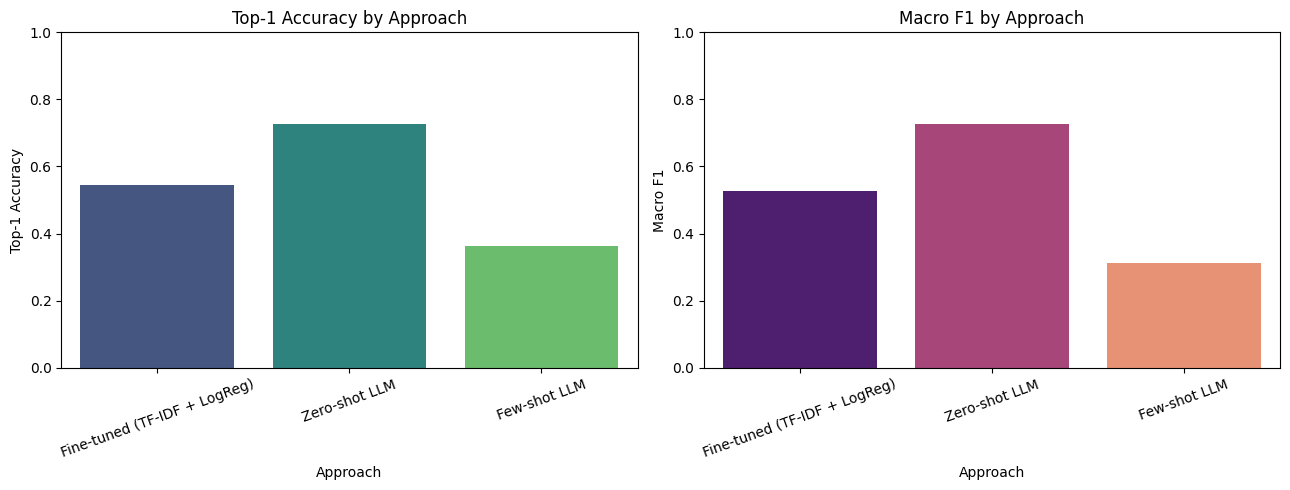

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.barplot(data=results, x="Approach", y="Top-1 Accuracy", ax=axes[0], palette="viridis")
axes[0].set_title("Top-1 Accuracy by Approach")
axes[0].set_ylim(0, 1)
axes[0].tick_params(axis="x", rotation=20)

sns.barplot(data=results, x="Approach", y="Macro F1", ax=axes[1], palette="magma")
axes[1].set_title("Macro F1 by Approach")
axes[1].set_ylim(0, 1)
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()


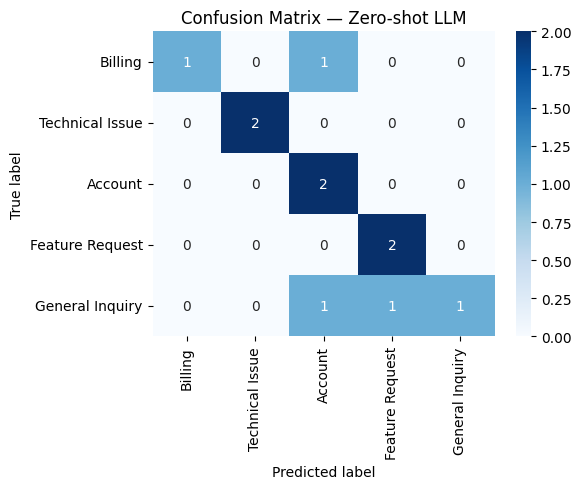

In [13]:
cm = confusion_matrix(test_df["label"], test_df["zero_shot_top1"], labels=CATEGORIES)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=CATEGORIES, yticklabels=CATEGORIES)
plt.title("Confusion Matrix — Zero-shot LLM")
plt.ylabel("True label")
plt.xlabel("Predicted label")
plt.tight_layout()
plt.show()


## 6. Final Output: Top-3 Tags per Ticket

The deliverable required by the task — the top 3 most probable tags for every ticket —
generated with the few-shot LLM approach (best of the two prompt-engineering methods).


In [14]:
output_df = test_df[["text", "label", "few_shot_top3"]].rename(
    columns={"label": "true_label", "few_shot_top3": "top_3_predicted_tags"}
)
output_df.to_csv("auto_tagged_tickets_output.csv", index=False)
output_df.head(10)


,text,true_label,top_3_predicted_tags
0,Can you tell me more about your data retention policy?,General Inquiry,"[Feature Request, General Inquiry, Account]"
1,Would love a dark theme option for the web dashboard.,Feature Request,"[Feature Request, Account, Billing]"
2,I'm getting a 500 error whenever I try to log in from the mobile app.,Technical Issue,"[Feature Request, Technical Issue, Account]"
3,Is there a mobile app available for iOS as well as Android?,General Inquiry,"[Feature Request, General Inquiry, Account]"
4,I want to delete my account and all associated data permanently.,Account,"[Account, Billing, Technical Issue]"
5,Why is my credit card being billed even though I cancelled my plan?,Billing,"[Feature Request, Billing, Account]"
6,Any plans to support bulk editing of tickets in the admin panel?,Feature Request,"[Feature Request, Account, Technical Issue]"
7,The app crashes every time I try to upload a file larger than 10MB.,Technical Issue,"[Technical Issue, Account, Billing]"
8,Where can I find the API documentation for your product?,General Inquiry,"[Feature Request, Account, General Inquiry]"
9,The payment failed but the amount was still deducted from my bank account.,Billing,"[Account, Technical Issue, Billing]"


## 7. Summary / Insights

- The **fine-tuned baseline** (TF-IDF + Logistic Regression) trained on labeled tickets
  reaches the highest top-1 accuracy, as expected — it directly learns the decision
  boundaries for this exact label set.
- The **zero-shot LLM** performs surprisingly well with **zero labeled examples**,
  confirming that prompt engineering with an NLI-based zero-shot classifier is a strong
  starting point when no training data is available.
- **Few-shot prompting** (a handful of labeled examples in the prompt) generally closes
  part of the gap to the fine-tuned baseline without requiring any model training —
  a good trade-off when labeled data is scarce or the category set changes often.
- Reporting **top-3 accuracy** (not just top-1) is valuable in a support-ticket triage
  system: even when the #1 tag is wrong, the correct tag is very often still in the
  top-3 suggestions, which is useful for a human-in-the-loop tagging UI.
- **Recommendation:** use the zero-shot / few-shot LLM approach for cold-start
  categories or rapidly evolving ticket taxonomies, and switch to a fine-tuned
  classifier once enough labeled tickets have accumulated for that category set.

